# Options pricing with Black-Scholes
This notebook demonstrates a selection of capabilities of the **Volaris** library:
- option pricing with the Black-Scholes model
- Greeks calculation: delta, gamma, vega, theta, rho
- fast root-finding and numerical integration through a compiled C core
- binomial tree as a discrete alternative to Black-Scholes

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from volaris import (
    bs_price, bs_delta, bs_gamma, bs_vega, bs_theta, bs_rho,
    binomial_price,
    rootfind_newton, rootfind_bisect,
    integrate_gauss, integrate_gsl,
    implied_vol,
)

S, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20

---

## Black-Scholes pricing

The Black-Scholes model assumes the underlying option follows Geometric Brownian Motion.

Variables used:
| Symbol | Meaning | Example value |
|--------|---------|---------------|
| S | current price of the underlying asset | 100.0 |
| K | strike price (exercise price of the option) | 100.0 |
| T | time to expiration in years | 1.0 (= 1 year) |
| r | risk-free interest rate (annualised) | 0.05 (= 5%) |
| sigma | volatility of the underlying (annualised) | 0.20 (= 20%) |
| C | call option price: right to buy at K | computed |
| P | put option price: right to sell at K | computed |

Call and put prices for an at-the-money option, verified via put-call parity:

In [2]:
call = bs_price(S, K, T, r, sigma, 1)
put  = bs_price(S, K, T, r, sigma, 0)

print(f"Call: {call:.4f}")
print(f"Put:  {put:.4f}")

print(f"Put-call parity check: {call - put:.4f} vs {S - K * np.exp(-r * T):.4f}")
if abs((call - put) - (S - K * np.exp(-r * T))) < 1e-10:
    print("Put-call parity holds!")

Call: 10.4506
Put:  5.5735
Put-call parity check: 4.8771 vs 4.8771
Put-call parity holds!


---

## Greeks calculation

The Greeks measure the sensitivity of the option price to market parameters.

Below: delta, gamma, vega, and theta for call and put options as a function of spot price S.

In [3]:
spots = np.linspace(60, 140, 200)

deltas_c = [bs_delta(s, K, T, r, sigma, 1) for s in spots]
deltas_p = [bs_delta(s, K, T, r, sigma, 0) for s in spots]
gammas = [bs_gamma(s, K, T, r, sigma) for s in spots]
vegas = [bs_vega(s, K, T, r, sigma) for s in spots]
thetas_c = [bs_theta(s, K, T, r, sigma, 1) for s in spots]
thetas_p = [bs_theta(s, K, T, r, sigma, 0) for s in spots]

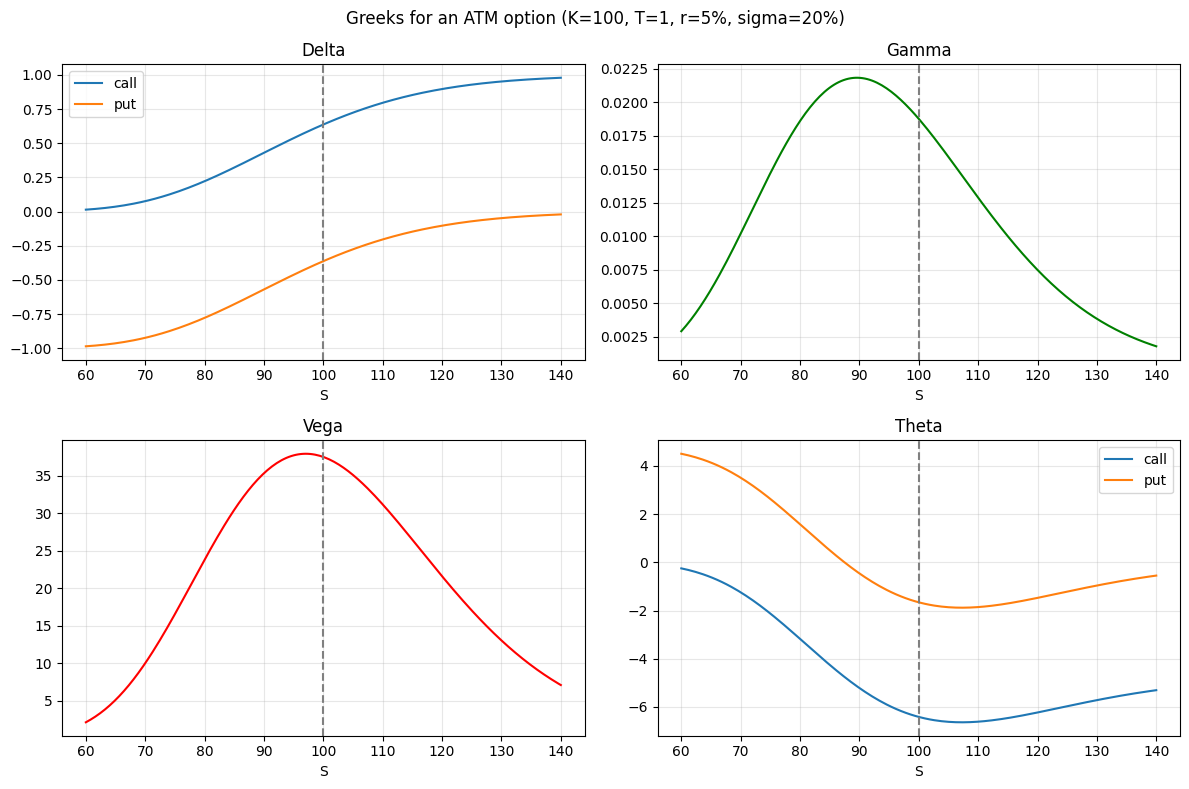

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(spots, deltas_c, label="call")
axes[0,0].plot(spots, deltas_p, label="put")
axes[0,0].set_title("Delta"); axes[0,0].legend()
axes[0,0].axvline(K, ls="--", c="gray")

axes[0,1].plot(spots, gammas, color="green")
axes[0,1].set_title("Gamma")
axes[0,1].axvline(K, ls="--", c="gray")

axes[1,0].plot(spots, vegas, color="red")
axes[1,0].set_title("Vega")
axes[1,0].axvline(K, ls="--", c="gray")

axes[1,1].plot(spots, thetas_c, label="call")
axes[1,1].plot(spots, thetas_p, label="put")
axes[1,1].set_title("Theta"); axes[1,1].legend()
axes[1,1].axvline(K, ls="--", c="gray")

for ax in axes.flat:
    ax.set_xlabel("S");
    ax.grid(alpha=0.3)

plt.suptitle("Greeks for an ATM option (K=100, T=1, r=5%, sigma=20%)")
plt.tight_layout()
plt.show()

---

## Root-finding

Volaris provides two root-finding methods implemented in C.

Example: find sigma such that the BS call price equals 15. This is also exactly what `implied_vol` does internally.


In [ ]:
target = 15.0

f = lambda sigma: bs_price(S, K, T, r, sigma, 1) - target
df = lambda sigma: bs_vega(S, K, T, r, sigma)

root_newton = rootfind_newton(f, df, x0=0.3)
root_bisect = rootfind_bisect(f, 0.01, 2.0)
iv = implied_vol(target, S, K, T, r, 1)

print(f"Target: {target}")
print("------------------")
print(f"Newton-Raphson:  sigma = {root_newton:.6f}  |  price = {bs_price(S, K, T, r, root_newton, 1):.6f}")
print(f"Bisection:       sigma = {root_bisect:.6f}  |  price = {bs_price(S, K, T, r, root_bisect, 1):.6f}")
print(f"Implied vol:     sigma = {iv:.6f}  |  price = {bs_price(S, K, T, r, iv, 1):.6f}")

Target: 15.0
------------------
Newton-Raphson:  sigma = 0.320258  |  price = 15.000000
Bisection:       sigma = 0.320258  |  price = 15.000000
Implied vol:     sigma = 0.320258  |  price = 15.000000


---

## Numerical integration

The Black-Scholes formula is derived from an integral over the normal distribution.

Comparison of Gauss quadrature (custom C implementation) and GSL QAGS adaptive integration:

In [6]:
from math import pi, exp, sqrt

def normal_pdf(x):
   return exp(-0.5 * x * x) / sqrt(2 * pi)

a, b = -3.0, 3.0
exact = 0.9973002039  # P(-3 < Z < 3)

result_gauss = integrate_gauss(normal_pdf, a, b, n_points=20)
result_gsl = integrate_gsl(normal_pdf, a, b, tol=1e-10)

print(f"Gauss quadrature (n=20): {result_gauss:.10f}  |  error: {abs(result_gauss - exact):.2e}")
print(f"GSL QAGS:                {result_gsl:.10f}  |  error: {abs(result_gsl - exact):.2e}")
print(f"Exact value:             {exact:.10f}")

Gauss quadrature (n=20): 0.9973002039  |  error: 3.67e-11
GSL QAGS:                0.9973002039  |  error: 3.67e-11
Exact value:             0.9973002039


---

## Options pricing with a binomial tree

The Cox-Ross-Rubinstein model demonstrates Brownian motion on a binomial tree.

As the number of steps N increases, the price converges to the Black-Scholes analytical value:

In [ ]:
bs_ref = bs_price(S, K, T, r, sigma, 1)
steps = [5, 10, 20, 50, 100, 200, 500]
prices = [binomial_price(S, K, T, r, 0.0, sigma, N, 1, 0) for N in steps]

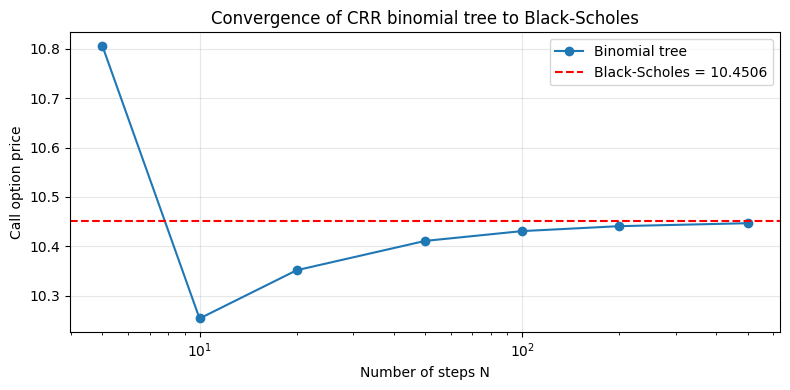

In [8]:
plt.figure(figsize=(8, 4))
plt.semilogx(steps, prices, "o-", label="Binomial tree")
plt.axhline(bs_ref, color="red", ls="--", label=f"Black-Scholes = {bs_ref:.4f}")
plt.xlabel("Number of steps N")
plt.ylabel("Call option price")
plt.title("Convergence of CRR binomial tree to Black-Scholes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()